# Curation of Cropped Images Dataset

In [1]:
import os
import shutil 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# 1) Import Full MOF Images Dataset

In [2]:
data_dir = os.getcwd()
files = os.path.join(data_dir, "2D_Grids_vdw_curated.npz")

# Load data
data = np.load(files, allow_pickle=True)
images = data["images"] 
names = data["names"].tolist()

print(f"Image shape: {images.shape}")

Image shape: (3855, 500, 500)


# 2) Crop Images

In [3]:

def crop_images(images, names, border_threshold=10):

    crop_images = []
    crop_names = []

    for i, img in enumerate(images):

        # Scale to 0-255 if necessary
        img_uint8 = (255 * img).astype(np.uint8)
        #img_uint8[img_uint8 > 0] = 255
        img_h, img_w = img_uint8.shape

        # Find contours
        contours, _ = cv2.findContours(img_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
         
        crop_number = 0

        for cnt in contours:
            x, y, w, h = cv2.boundingRect(cnt)

            # Skip contours touching the image border
            if x <= border_threshold or y <= border_threshold or (x + w) >= (img_w - border_threshold) or (y + h) >= (img_h - border_threshold):
                continue

            cropped = img_uint8[y:y+h, x:x+w]
            cropped = cropped.astype(np.float32) / 255.0

            # Save cropped image
            base_name = names[i]
            crop_name = f"{base_name}_crop_{crop_number}"
            crop_images.append(cropped)
            crop_names.append(crop_name)

            crop_number += 1

    return crop_images, crop_names


In [4]:
crop_images, crop_names = crop_images(images, names, border_threshold=10)
print(f"Total raw cropped images: {len(crop_names)}")

Total raw cropped images: 107731


In [5]:
def resize_and_filter_crops(crop_images, crop_names, crop_size=24, min_area=1000):

    processed = []
    selected_names = []

    for img, name in zip(crop_images, crop_names):

        if img is None:
            continue

        h, w = img.shape
        if h * w < min_area:
            continue

        # resize to square while preserving aspect ratio
        scale = crop_size / max(h, w)
        new_w = max(1, int(w * scale))
        new_h = max(1, int(h * scale))

        resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        #resized = (resized > 0.5).astype(np.float32) # re-binarize

        canvas = np.zeros((crop_size, crop_size), dtype=resized.dtype)
        y = (crop_size - new_h) // 2
        x = (crop_size - new_w) // 2
        canvas[y:y+new_h, x:x+new_w] = resized
        
        img2 = canvas.astype(np.float32)

        processed.append(img2)
        selected_names.append(name)

    return np.array(processed, dtype=np.float32), selected_names


In [6]:
crop_images_resized, crop_names_resized = resize_and_filter_crops(crop_images, crop_names, crop_size=24, min_area=1000)
print(f"Remaining {len(crop_images_resized)} crop images")
print(f"Cropped image shape: {crop_images_resized.shape}")

Remaining 55896 crop images
Cropped image shape: (55896, 24, 24)


In [7]:
# --- Save compressed ---
out_file = os.path.join(data_dir, "cropped_images_raw.npz")
np.savez_compressed(out_file, images=crop_images_resized, names=crop_names_resized)

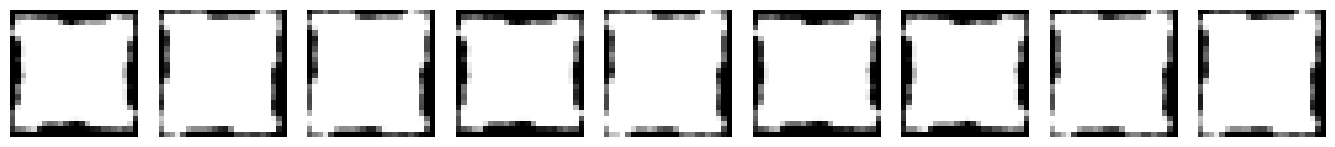

In [8]:
# visulize one example
selected_name = 'HOFJIX_full'

# Find indices of crops matching the target name
indices = [i for i, name in enumerate(crop_names_resized) if name.startswith(selected_name)]

# Limit to first 20 crops
num_plot = min(20, len(indices))

fig=plt.figure(figsize=(15, 3))
for i in range(num_plot):
    idx = indices[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(crop_images_resized[idx], cmap='gray')
    #plt.xticks([])
    #plt.yticks([])
    plt.axis('off')
    #plt.title(names_crops[idx])
plt.tight_layout()


# 3) Pad cropped Images

In [9]:
def apply_padding(images, padding=4):

    if padding == 0:
        return images

    N, H, W = images.shape
    H2, W2 = H + 2*padding, W + 2*padding

    padded = np.zeros((N, H2, W2), dtype=images.dtype)
    padded[:, padding:padding+H, padding:padding+W] = images
    return padded

In [10]:
crop_images_padded = apply_padding(crop_images_resized, padding=4)
print(f"Padded image shape: {crop_images_padded.shape}")

Padded image shape: (55896, 32, 32)


In [11]:
# --- Save compressed ---
out_file = os.path.join(data_dir, "cropped_images_padded.npz")
np.savez_compressed(out_file, images=crop_images_padded, names=crop_names_resized)

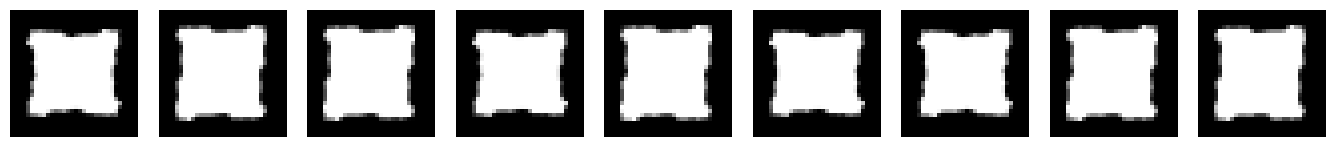

In [12]:
# visulize padded image
selected_name = 'HOFJIX_full'

# Find indices of crops matching the target name
indices = [i for i, name in enumerate(crop_names_resized) if name.startswith(selected_name)]

# Limit to first 20 crops
num_plot = min(20, len(indices))

fig=plt.figure(figsize=(15, 3))
for i in range(num_plot):
    idx = indices[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(crop_images_padded[idx], cmap='gray')
    #plt.xticks([])
    #plt.yticks([])
    plt.axis('off')
    #plt.title(names_crops[idx])
plt.tight_layout()


# 4) Rotate cropped Images

In [13]:
def apply_random_rotation(images, seed=4224):

    rng = np.random.default_rng(seed)   # reproducible generator

    N, H, W = images.shape
    rotated = np.zeros_like(images)

    for i in range(N):
        angle = rng.uniform(0, 360)    # different angle per image but deterministic
        M = cv2.getRotationMatrix2D((W // 2, H // 2), angle, 1.0)
        rot = cv2.warpAffine(images[i], M, (W, H), borderValue=0)
        rotated[i] = rot

    return rotated


In [14]:
crop_images_rotated = apply_random_rotation(crop_images_padded, seed=4224)
print(f"Rotated image shape: {crop_images_padded.shape}")

Rotated image shape: (55896, 32, 32)


In [15]:
# --- Save compressed ---
out_file = os.path.join(data_dir, "cropped_images_rotated.npz")
np.savez_compressed(out_file, images=crop_images_rotated, names=crop_names_resized)

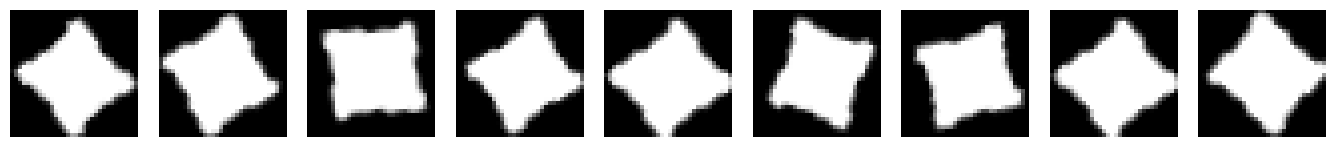

In [17]:
# visulize rotated image
selected_name = 'HOFJIX_full'

# Find indices of crops matching the target name
indices = [i for i, name in enumerate(crop_names_resized) if name.startswith(selected_name)]

# Limit to first 20 crops
num_plot = min(20, len(indices))

fig=plt.figure(figsize=(15, 3))
for i in range(num_plot):
    idx = indices[i]
    plt.subplot(2, 10, i+1)
    plt.imshow(crop_images_rotated[idx], cmap='gray')
    #plt.xticks([])
    #plt.yticks([])
    plt.axis('off')
    #plt.title(names_crops[idx])
plt.tight_layout()
